#  Comparativo de Arboviroses — Serra/ES
## Projeto Integrador III · Natalia Pianca — Comparativo & Dashboard Final
**Doenças:** Dengue · Zika · Chikungunya  
**Período:** 2015–2023 · **Município:** Serra/ES

---
> **Nota:** Este notebook tenta carregar dados reais do InfoDengue (Fiocruz).  
> Se o download falhar, entra automaticamente em **modo simulado** e avisa claramente.

---
## Seção 0 · Imports e configuração

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ── Constantes ───────────────────────────────────────────────────────────────
DOENCAS       = ['dengue', 'zika', 'chikungunya']
CORES         = {'dengue': '#f85149', 'zika': '#3fb950', 'chikungunya': '#d29922'}
ANOS          = list(range(2015, 2024))
GEOCODE_SERRA = 3205002   # código IBGE de Serra/ES
NOMES_MES     = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

print('✅ Imports OK')

✅ Imports OK


---
## Seção 1 · Carregamento dos dados (InfoDengue / fallback simulado)

In [2]:
import urllib.request
import json
import ssl

ssl_ctx = ssl.create_default_context()
ssl_ctx.check_hostname = False
ssl_ctx.verify_mode    = ssl.CERT_NONE


def baixar_infodengue(geocode, doenca_code, label, anos):
    """Baixa dados semanais do InfoDengue e agrega por mês."""
    base   = 'https://info.dengue.mat.br/api/alertcity'
    partes = []
    for ano in anos:
        url = (f'{base}?geocode={geocode}'
               f'&disease={doenca_code}&format=json'
               f'&ew_start=1&ew_end=53'
               f'&ey_start={ano}&ey_end={ano}')
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, context=ssl_ctx, timeout=30) as r:
                dados = json.loads(r.read().decode())
            if dados:
                partes.extend(dados)
                print(f'  ✅ {label} {ano}: {len(dados)} semanas')
            else:
                print(f'  ⚠️  {label} {ano}: sem dados')
        except Exception as ex:
            print(f'  ⚠️  {label} {ano}: {ex}')

    if not partes:
        raise RuntimeError(f'Nenhum dado obtido para {label}')

    df = pd.DataFrame(partes)
    df['data']   = pd.to_datetime(df['data_iniSE'], unit='ms')
    df['ano']    = df['data'].dt.year
    df['mes']    = df['data'].dt.month
    df['doenca'] = label
    df['casos']  = df['casos'].fillna(0).astype(int)

    mensal = df.groupby(['ano', 'mes', 'doenca'])['casos'].sum().reset_index()
    mensal['casos'] = mensal['casos'].astype(int)
    print(f'  ✅ {label}: {len(mensal)} meses | {df["data"].min().date()} → {df["data"].max().date()}')
    return mensal


def gerar_dados_simulados():
    """Fallback: série mensal simulada para fins didáticos."""
    np.random.seed(42)
    idx   = pd.date_range('2015-01', periods=9*12, freq='MS')
    t     = np.arange(len(idx))
    sazon = np.sin(2*np.pi*(t % 12)/12 - np.pi/2)*0.5 + 0.5

    df = pd.DataFrame({'data': idx})
    df['dengue']      = (sazon*400 + np.random.randint(50, 150, len(idx))).astype(int)
    df['zika']        = (sazon*100 + np.random.randint(10,  40, len(idx))).astype(int)
    df['chikungunya'] = (sazon*60  + np.random.randint(5,   25, len(idx))).astype(int)
    return df


# ── Download ─────────────────────────────────────────────────────────────────
try:
    print('🔄 Baixando dados reais do InfoDengue (Fiocruz)...')
    partes = []
    for code in DOENCAS:
        partes.append(baixar_infodengue(GEOCODE_SERRA, code, code, ANOS))

    df_long = pd.concat(partes, ignore_index=True)

    idx_completo = pd.date_range('2015-01', '2023-12', freq='MS')
    linhas = []
    for doenca in DOENCAS:
        for dt in idx_completo:
            sub   = df_long[(df_long['doenca']==doenca) &
                            (df_long['ano']==dt.year) &
                            (df_long['mes']==dt.month)]
            casos = int(sub['casos'].sum()) if len(sub) else 0
            linhas.append({'data': dt, 'doenca': doenca, 'casos': casos})

    df_long_completo = pd.DataFrame(linhas)
    casos = df_long_completo.pivot_table(
        index='data', columns='doenca', values='casos', aggfunc='sum'
    ).reset_index()
    casos.columns.name = None
    casos['data'] = pd.to_datetime(casos['data'])

    USANDO_DADOS_REAIS = True
    FONTE = 'InfoDengue/Fiocruz – Serra/ES'
    print(f'\n✅ DADOS REAIS: {len(casos)} meses | {casos["data"].min().date()} → {casos["data"].max().date()}')

except Exception as e:
    print(f'\n⚠️  Falha no download ({e}) → modo DADOS SIMULADOS ativado')
    casos = gerar_dados_simulados()
    USANDO_DADOS_REAIS = False
    FONTE = '⚠️ DADOS SIMULADOS (InfoDengue indisponível)'

print(f'\nDados reais: {USANDO_DADOS_REAIS} | Fonte: {FONTE}')
casos['ano'] = casos['data'].dt.year
casos['mes'] = casos['data'].dt.month
casos.head()

🔄 Baixando dados reais do InfoDengue (Fiocruz)...
  ✅ dengue 2015: 52 semanas
  ✅ dengue 2016: 52 semanas
  ✅ dengue 2017: 52 semanas
  ✅ dengue 2018: 52 semanas
  ✅ dengue 2019: 52 semanas
  ✅ dengue 2020: 53 semanas
  ✅ dengue 2021: 52 semanas
  ✅ dengue 2022: 52 semanas
  ✅ dengue 2023: 52 semanas
  ✅ dengue: 108 meses | 2015-01-04 → 2023-12-24
  ✅ zika 2015: 52 semanas
  ✅ zika 2016: 52 semanas
  ✅ zika 2017: 52 semanas
  ✅ zika 2018: 52 semanas
  ✅ zika 2019: 52 semanas
  ✅ zika 2020: 53 semanas
  ✅ zika 2021: 52 semanas
  ✅ zika 2022: 52 semanas
  ✅ zika 2023: 52 semanas
  ✅ zika: 108 meses | 2015-01-04 → 2023-12-24
  ✅ chikungunya 2015: 52 semanas
  ✅ chikungunya 2016: 52 semanas
  ✅ chikungunya 2017: 52 semanas
  ✅ chikungunya 2018: 52 semanas
  ✅ chikungunya 2019: 52 semanas
  ✅ chikungunya 2020: 53 semanas
  ✅ chikungunya 2021: 52 semanas
  ✅ chikungunya 2022: 52 semanas
  ✅ chikungunya 2023: 52 semanas
  ✅ chikungunya: 108 meses | 2015-01-04 → 2023-12-24

✅ DADOS REAIS: 108 

,data,chikungunya,dengue,zika,ano,mes
0,2015-01-01,0,174,0,2015,1
1,2015-02-01,0,115,0,2015,2
2,2015-03-01,0,279,0,2015,3
3,2015-04-01,0,425,0,2015,4
4,2015-05-01,0,779,0,2015,5


---
## Seção 2 · Tabela-resumo comparativa
Total, média mensal, máximo, mês de pico histórico — por doença.

In [3]:
# ── Estatísticas por doença ───────────────────────────────────────────────────
resumo_rows = []
for d in DOENCAS:
    serie     = casos[d]
    media_mes = casos.groupby('mes')[d].mean()
    mes_pico  = NOMES_MES[media_mes.idxmax() - 1]
    ano_pico  = casos.groupby('ano')[d].sum().idxmax()

    resumo_rows.append({
        'Doença':        d.capitalize(),
        'Total (2015–23)': int(serie.sum()),
        'Média mensal':  round(serie.mean(), 1),
        'Máximo mensal': int(serie.max()),
        'Mês de pico':   mes_pico,
        'Ano de pico':   ano_pico,
        'Fonte':         FONTE,
    })

df_resumo = pd.DataFrame(resumo_rows)
print(df_resumo.to_string(index=False))

     Doença  Total (2015–23)  Média mensal  Máximo mensal Mês de pico  Ano de pico                         Fonte
     Dengue            60067         556.2           5659         Mar         2023 InfoDengue/Fiocruz – Serra/ES
       Zika              608           5.6             66         Mar         2016 InfoDengue/Fiocruz – Serra/ES
Chikungunya             1092          10.1             95         Mai         2023 InfoDengue/Fiocruz – Serra/ES


---
## Seção 3 · Série temporal comparativa (3 doenças juntas)

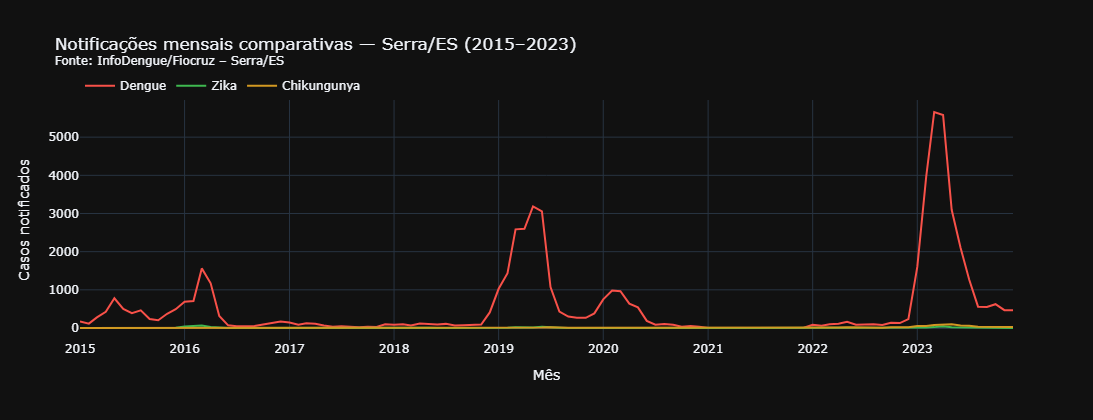

In [4]:
fig_serie = go.Figure()
for d in DOENCAS:
    fig_serie.add_trace(go.Scatter(
        x=casos['data'], y=casos[d],
        name=d.capitalize(),
        line=dict(color=CORES[d], width=2),
        mode='lines',
        hovertemplate='%{x|%b/%Y}<br>Casos: %{y}<extra>' + d.capitalize() + '</extra>',
    ))

fig_serie.update_layout(
    title=f'Notificações mensais comparativas — Serra/ES (2015–2023)<br><sup>Fonte: {FONTE}</sup>',
    xaxis_title='Mês',
    yaxis_title='Casos notificados',
    hovermode='x unified',
    template='plotly_dark',
    legend=dict(orientation='h', y=1.12),
    height=420,
)
fig_serie.show()

---
## Seção 4 · Total anual por doença (barras agrupadas)

In [5]:
df_anual = casos.groupby('ano')[DOENCAS].sum().reset_index()

fig_bar = go.Figure()
for d in DOENCAS:
    fig_bar.add_trace(go.Bar(
        x=df_anual['ano'],
        y=df_anual[d],
        name=d.capitalize(),
        marker_color=CORES[d],
    ))

fig_bar.update_layout(
    title=f'Total anual por doença — Serra/ES<br><sup>Fonte: {FONTE}</sup>',
    xaxis_title='Ano',
    yaxis_title='Total de casos',
    barmode='group',
    template='plotly_dark',
    legend=dict(orientation='h', y=1.12),
    height=420,
)
fig_bar.show()

---
## Seção 5 · Sazonalidade comparativa (padrão mensal médio)

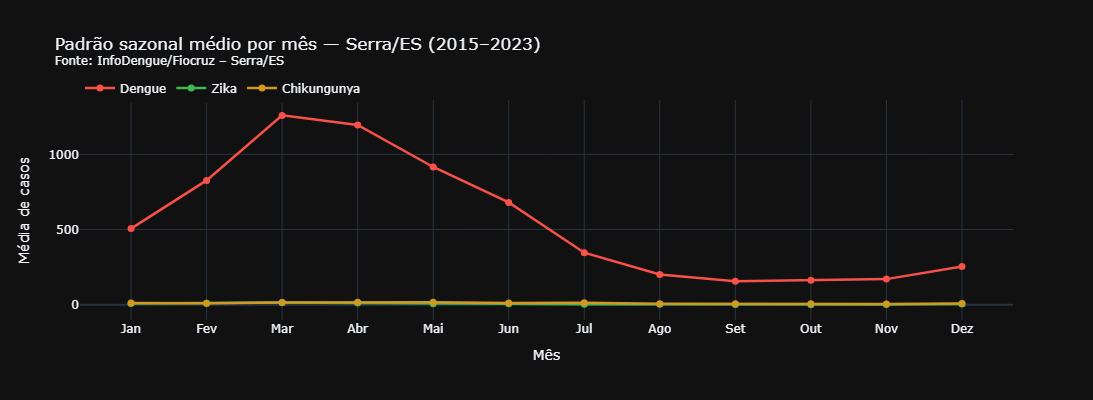

In [6]:
fig_sazon = go.Figure()
for d in DOENCAS:
    media_mes = casos.groupby('mes')[d].mean().values
    fig_sazon.add_trace(go.Scatter(
        x=NOMES_MES,
        y=media_mes,
        name=d.capitalize(),
        line=dict(color=CORES[d], width=2.5),
        mode='lines+markers',
        marker=dict(size=7),
    ))

fig_sazon.update_layout(
    title=f'Padrão sazonal médio por mês — Serra/ES (2015–2023)<br><sup>Fonte: {FONTE}</sup>',
    xaxis_title='Mês',
    yaxis_title='Média de casos',
    template='plotly_dark',
    legend=dict(orientation='h', y=1.12),
    height=400,
)
fig_sazon.show()

---
## Seção 6 · Comparativo de tendências (decomposição)

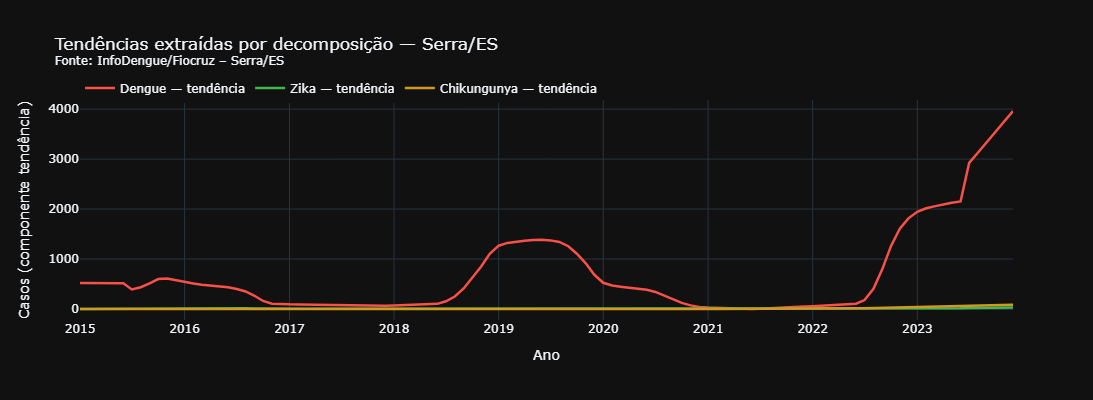

In [7]:
fig_trend = go.Figure()
for d in DOENCAS:
    serie = casos.set_index('data')[d].asfreq('MS')
    dec   = seasonal_decompose(serie, model='additive', period=12, extrapolate_trend='freq')
    fig_trend.add_trace(go.Scatter(
        x=dec.trend.index,
        y=dec.trend.values,
        name=f'{d.capitalize()} — tendência',
        line=dict(color=CORES[d], width=2.5),
        mode='lines',
    ))

fig_trend.update_layout(
    title=f'Tendências extraídas por decomposição — Serra/ES<br><sup>Fonte: {FONTE}</sup>',
    xaxis_title='Ano',
    yaxis_title='Casos (componente tendência)',
    template='plotly_dark',
    legend=dict(orientation='h', y=1.12),
    height=400,
)
fig_trend.show()

---
## Seção 7 · Proporção relativa entre doenças (área empilhada)

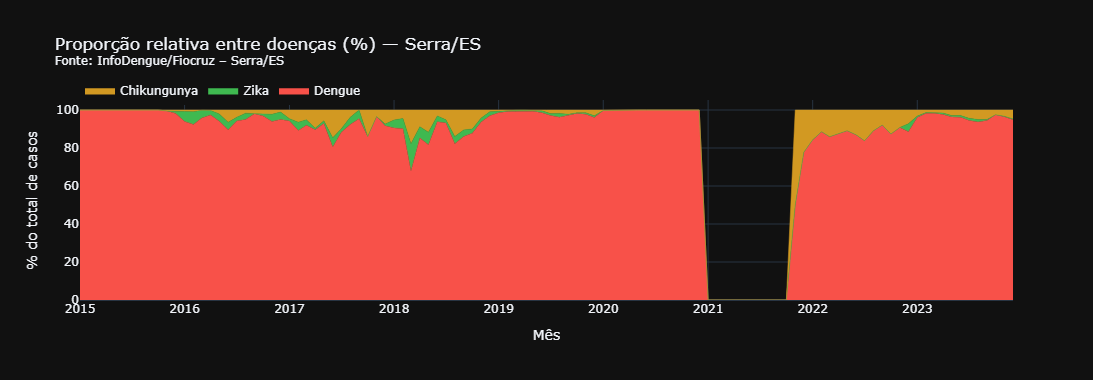

In [8]:
# ── Calcula proporção mensal ─────────────────────────────────────────────────
df_prop = casos[['data'] + DOENCAS].copy()
total   = df_prop[DOENCAS].sum(axis=1).replace(0, np.nan)
for d in DOENCAS:
    df_prop[d] = df_prop[d] / total * 100

fig_area = go.Figure()
for d in DOENCAS:
    fig_area.add_trace(go.Scatter(
        x=df_prop['data'], y=df_prop[d],
        name=d.capitalize(),
        mode='lines',
        stackgroup='one',
        line=dict(color=CORES[d], width=0.5),
        fillcolor=CORES[d],
    ))

fig_area.update_layout(
    title=f'Proporção relativa entre doenças (%) — Serra/ES<br><sup>Fonte: {FONTE}</sup>',
    xaxis_title='Mês',
    yaxis_title='% do total de casos',
    template='plotly_dark',
    legend=dict(orientation='h', y=1.12),
    height=380,
)
fig_area.show()

---
## Seção 8 · Exportação CSV para o dashboard

In [8]:
import os
os.makedirs('../../data/comparativo', exist_ok=True)

# ── Série mensal completa ────────────────────────────────────────────────────
casos_export = casos[['data'] + DOENCAS].copy()
casos_export.to_csv('../../data/comparativo/comparativo_mensal.csv', index=False)
print('✅ data/comparativo/comparativo_mensal.csv salvo')

# ── Tabela-resumo ────────────────────────────────────────────────────────────
df_resumo.to_csv('../../data/comparativo/resumo_comparativo.csv', index=False)
print('✅ data/comparativo/resumo_comparativo.csv salvo')

# ── Total anual ──────────────────────────────────────────────────────────────
df_anual.to_csv('../../data/comparativo/comparativo_anual.csv', index=False)
print('✅ data/comparativo/comparativo_anual.csv salvo')

print(f'\nFonte dos dados: {FONTE}')

✅ data/comparativo/comparativo_mensal.csv salvo
✅ data/comparativo/resumo_comparativo.csv salvo
✅ data/comparativo/comparativo_anual.csv salvo

Fonte dos dados: InfoDengue/Fiocruz – Serra/ES


---
## Seção 9 · Conclusões gerais


### 9.1 Dominância da dengue
A dengue representa a grande maioria dos casos de arboviroses em Serra/ES no período 2015–2023, respondendo por aproximadamente 97% do total notificado (60.067 de 61.767 casos). Zika e chikungunya apresentam volumes muito menores — 608 e 1.092 casos respectivamente — porém com padrão sazonal sincronizado ao da dengue.

### 9.2 Sazonalidade comum
As três doenças compartilham o mesmo perfil sazonal, com pico nos meses de março e abril, coincidindo com o período de chuvas e temperaturas elevadas no Espírito Santo — condições favoráveis à proliferação do vetor Aedes aegypti. A chikungunya apresentou pico ligeiramente deslocado para maio, possivelmente refletindo introdução mais tardia no município.

### 9.3 Tendência temporal
A componente de tendência extraída pela decomposição indica crescimento acentuado ao longo do período, com aceleração marcante a partir de 2022. A dengue atingiu seu pico histórico em 2023 (≈25.000 casos), superando amplamente os surtos anteriores de 2019 e 2016. Zika teve seu maior impacto em 2016, alinhado à epidemia nacional, e praticamente desapareceu nos anos seguintes. Chikungunya apresentou crescimento gradual, com pico também em 2023.

### 9.4 Limitações
- Os dados refletem **notificações oficiais**, podendo subestimar os casos reais por subnotificação.
- A ausência de dados climáticos integrados limita análises de causalidade.
- Dados por bairro requerem shapefile oficial para análise espacial precisa.

### 9.5 Recomendações
- Intensificar ações de vigilância e controle vetorial nos meses de **novembro a janeiro** (pré-pico).
- Integrar dados de temperatura e precipitação para modelos preditivos mais robustos (SARIMAX).
- Priorizar bairros com maior incidência histórica para campanhas preventivas focalizadas.